In [80]:
import torch.nn as nn
import torch
from torchvision import models
from torchvision.models import ResNet34_Weights
from PIL import Image
import torchvision.transforms as transforms
import os
import random
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F
from torchvision.transforms import functional as TF, InterpolationMode

In [3]:
model = models.resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)

In [60]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size = 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.1, inplace=True),    
        )
    def forward(self,x):
        return self.block(x)

In [61]:
class Up(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        self.reduce = nn.Conv2d(in_channels, out_channels, kernel_size=1)

        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        x = self.reduce(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

In [148]:
class UNet_AE(nn.Module):
    def __init__(self):
        super().__init__()
        model = models.resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)

        self.stage0 = nn.Sequential(
            model.conv1,
            model.bn1,
            model.relu,
            model.maxpool
        )
        self.stage1 = model.layer1
        self.stage2 = model.layer2
        self.stage3 = model.layer3
        self.stage4 = model.layer4

        self.up1 = Up(512, 256, 256)
        self.up2 = Up(256, 128, 128)
        self.up3 = Up(128, 64, 64)
        self.up4 = Up(64, 64, 32)
        self.up5 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            DoubleConv(32, 32)
        )
        self.outc = nn.Sequential(
            nn.Conv2d(32, 3, kernel_size = 1),
            nn.Sigmoid()    
        )

    def forward(self, x):
        x0 = self.stage0(x)
        x1 = self.stage1(x0)
        x2 = self.stage2(x1)
        x3 = self.stage3(x2)
        x4 = self.stage4(x3)
        f1 = self.up1(x4, x3)
        f2 = self.up2(f1, x2)
        f3 = self.up3(f2, x1)
        f4 = self.up4(f3, x0)
        f5 = self.up5(f4)
        return self.outc(f5)

In [152]:
import torch
import torch.nn as nn


class UNet_AE(nn.Module):
    def __init__(self, n_channels=3):
        super().__init__()

        # Encoder
        self.inc = DoubleConv(n_channels, 32)

        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        self.down4 = Down(256, 512)

        # Decoder
        self.up1 = Up(512, 256, 256)
        self.up2 = Up(256, 128, 128)
        self.up3 = Up(128, 64, 64)
        self.up4 = Up(64, 32, 32)

        self.outc = nn.Sequential(
            nn.Conv2d(32, 3, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):

        # Encoder
        x1 = self.inc(x)       # 32
        x2 = self.down1(x1)    # 64
        x3 = self.down2(x2)    # 128
        x4 = self.down3(x3)    # 256
        x5 = self.down4(x4)    # 512

        # Decoder
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.outc(x)



class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)



class Up(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.Upsample(
            scale_factor=2,
            mode="bilinear",
            align_corners=False
        )

        self.conv = DoubleConv(
            in_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        # Handles odd-sized images
        diff_y = skip.size()[2] - x.size()[2]
        diff_x = skip.size()[3] - x.size()[3]

        if diff_x != 0 or diff_y != 0:
            x = nn.functional.pad(
                x,
                [
                    diff_x // 2,
                    diff_x - diff_x // 2,
                    diff_y // 2,
                    diff_y - diff_y // 2
                ]
            )

        x = torch.cat([skip, x], dim=1)

        return self.conv(x)



class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.1, inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [154]:
img = Image.open('dog.jpg').convert("RGB")
img = transforms.Resize((256,256))(img)
img = transforms.ToTensor()(img)

In [155]:
with torch.no_grad():
    output = model(img.unsqueeze(0))

In [156]:
output.shape

torch.Size([1, 3, 256, 256])

In [77]:
device = torch.device('cuda' if torch.cuda.is_available else 'cpu')

In [153]:
model  = UNet_AE()

In [157]:
class ImageDataset(Dataset):
    def __init__(self, image_dir, image_names = None, split_file = None, transform = None):
        self.image_dir = image_dir
        self.transform = transform #optinal augmentations
        if (image_names is None) == (split_file is None):
            raise ValueError("Provide exactly one of image_names or split_file.")
        if split_file is not None:
            with open(split_file, 'r') as f:
                self.images = [line.strip().split()[0] + '.jpg' for line in f]
        else:
            self.images = [name + '.jpg' for name in image_names]
            
        self.image_transform = transforms.Compose([transforms.Resize((256,256)),
                                                   transforms.ToTensor()
                                                  ])
                                                       
    
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self,idx):
        image_name = self.images[idx]
        image_path = os.path.join(self.image_dir, image_name)
        
    
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)
    
        image = self.image_transform(image)
    
        return image

In [158]:
class ImageTransform:
    def __call__(self, image):

        if random.random() < 0.5:
            image = TF.hflip(image)

        if random.random() < 0.2:
            angle = random.uniform(-5,5)

            image = TF.affine(
                image,
                angle=angle,
                translate=(0,0),
                scale=1.0,
                shear=0,
                interpolation=InterpolationMode.BILINEAR
            )
        return image

In [159]:
with open('Dataset/trainval.txt','r') as f:
    image_names = [line.strip().split()[0] for line in  f]

In [160]:
train_names, val_names = train_test_split(image_names, test_size = 0.15, random_state=42, shuffle=True)

In [161]:
train_transform = ImageTransform()

In [162]:
train_dataset = ImageDataset('dataset/images', image_names=train_names, transform=train_transform)

In [163]:
val_dataset = ImageDataset('dataset/images', image_names=val_names)

In [164]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle = True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle= False, num_workers=0)

In [165]:
val_noise_generator = torch.Generator(device=device)
val_noise_generator.manual_seed(42)

In [166]:
def add_random_gaussian_noise(images, sigma_range=(0.01, 0.1), generator=None):
    single_image = images.dim() == 3
    if single_image:
        images = images.unsqueeze(0)
    B = images.size(0)
    sigmas = torch.empty(B, 1, 1, 1, device=images.device).uniform_(sigma_range[0], sigma_range[1], generator=generator)
    noise = torch.randn_like(images, generator=generator)
    noisy = torch.clamp(images + noise * sigmas, 0, 1)
    if single_image:
        noisy = noisy.squeeze(0)
    return noisy

In [167]:
def validate(model, loader, device):

    model.eval()

    running_loss = 0

    with torch.no_grad():

        for images in loader:

            images = images.to(device)
            
            noisy_images = add_random_gaussian_noise(images, generator=val_noise_generator)

            outputs = model(noisy_images)

            loss = 0.6*l1(outputs, images) + 0.4*mse(outputs, images)

            running_loss += loss.item()

    return (running_loss / len(loader))

In [168]:
def train_one_epoch(model, loader, optimizer, device):

    model.train()

    running_loss = 0

    progress_bar = tqdm(loader, desc="Training")


    for images in progress_bar:

        images = images.to(device)
            
        noisy_images = add_random_gaussian_noise(images)

        outputs = model(noisy_images)

        loss = 0.6*l1(outputs, images) + 0.4*mse(outputs, images)

        optimizer.zero_grad()  

        loss.backward()  

        optimizer.step()

        running_loss += loss.item()

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader)

In [169]:
def train_model(model, train_loader, val_loader, optimizer, scheduler, epochs, device, lowest_val_loss = 10000, best_epoch=0, initial_epoch = 0, counter = 0):
    patience = 7

    for epoch in range(initial_epoch, epochs):

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            device
        )

        val_loss = validate(
            model,
            val_loader,
            device
        )

        scheduler.step(val_loss)
        lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"LR: {lr:.6f}"
        )

        if val_loss < lowest_val_loss:
            lowest_val_loss = val_loss
            best_epoch = epoch + 1
            counter = 0

            torch.save(model.state_dict(), "best_denoiser.pth")
            print("✓ Best model saved!")

        else:
            counter += 1
            print(f"No improvement: {counter}/{patience}")

            if counter >= patience:
                print("Early stopping!")
                break

        print(f"Best val loss: {lowest_val_loss:.4f} at epoch {best_epoch}\n")

    return lowest_val_loss, best_epoch

In [170]:
model = UNet_AE().to(device)

In [176]:
l1 = nn.L1Loss()
mse = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode = "min",
    factor = 0.1,
    patience=3,
    min_lr=1e-6
)

In [177]:
for name, param in model.named_parameters():
    if name.startswith("down"):
        param.requires_grad = False

In [178]:
for name, param in model.named_parameters():
    if name.startswith("down"):
        print(name, param.requires_grad)

down1.block.1.block.0.weight False
down1.block.1.block.0.bias False
down1.block.1.block.1.weight False
down1.block.1.block.1.bias False
down1.block.1.block.3.weight False
down1.block.1.block.3.bias False
down1.block.1.block.4.weight False
down1.block.1.block.4.bias False
down2.block.1.block.0.weight False
down2.block.1.block.0.bias False
down2.block.1.block.1.weight False
down2.block.1.block.1.bias False
down2.block.1.block.3.weight False
down2.block.1.block.3.bias False
down2.block.1.block.4.weight False
down2.block.1.block.4.bias False
down3.block.1.block.0.weight False
down3.block.1.block.0.bias False
down3.block.1.block.1.weight False
down3.block.1.block.1.bias False
down3.block.1.block.3.weight False
down3.block.1.block.3.bias False
down3.block.1.block.4.weight False
down3.block.1.block.4.bias False
down4.block.1.block.0.weight False
down4.block.1.block.0.bias False
down4.block.1.block.1.weight False
down4.block.1.block.1.bias False
down4.block.1.block.3.weight False
down4.block.1

In [179]:
train_model(model, train_loader,val_loader, optimizer,scheduler,epochs=5, device = device)

Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:10<00:00,  2.79it/s, loss=0.0234]


Epoch 1/5 | Train Loss: 0.0215 | Val Loss: 0.0133 | LR: 0.000100
✓ Best model saved!
Best val loss: 0.0133 at epoch 1



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:08<00:00,  2.86it/s, loss=0.0263]


Epoch 2/5 | Train Loss: 0.0205 | Val Loss: 0.0152 | LR: 0.000100
No improvement: 1/7
Best val loss: 0.0133 at epoch 1



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:07<00:00,  2.90it/s, loss=0.0451]


...

Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:08<00:00,  2.86it/s, loss=0.0216]


Epoch 4/5 | Train Loss: 0.0189 | Val Loss: 0.0129 | LR: 0.000100
✓ Best model saved!
Best val loss: 0.0129 at epoch 4



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:09<00:00,  2.84it/s, loss=0.0298]


Epoch 5/5 | Train Loss: 0.0182 | Val Loss: 0.0136 | LR: 0.000100
No improvement: 1/7
Best val loss: 0.0129 at epoch 4



(0.012856464699975081, 4)

In [180]:
for name, param in model.named_parameters():
    if name.startswith("down"):
        param.requires_grad = True

In [181]:
optimizer = torch.optim.Adam([
    {
        "params": [p for n, p in model.named_parameters() 
                   if n.startswith("down")],
        "lr": 1e-5
    },
    {
        "params": [p for n, p in model.named_parameters() 
                   if not n.startswith("down")],
        "lr": 1e-4
    }
])

In [182]:
train_model(model, train_loader,val_loader, optimizer,scheduler,epochs=10, initial_epoch=5, best_epoch=4, lowest_val_loss=0.0129, device = device)

Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:10<00:00,  2.77it/s, loss=0.0198]


Epoch 6/10 | Train Loss: 0.0181 | Val Loss: 0.0133 | LR: 0.000010
No improvement: 1/7
Best val loss: 0.0129 at epoch 4



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:11<00:00,  2.73it/s, loss=0.0174]


Epoch 7/10 | Train Loss: 0.0168 | Val Loss: 0.0139 | LR: 0.000010
No improvement: 2/7
Best val loss: 0.0129 at epoch 4



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:11<00:00,  2.74it/s, loss=0.0126]


...

Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:12<00:00,  2.72it/s, loss=0.0168]


Epoch 9/10 | Train Loss: 0.0159 | Val Loss: 0.0122 | LR: 0.000010
No improvement: 1/7
Best val loss: 0.0121 at epoch 8



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:10<00:00,  2.77it/s, loss=0.0153]


Epoch 10/10 | Train Loss: 0.0161 | Val Loss: 0.0123 | LR: 0.000010
No improvement: 2/7
Best val loss: 0.0121 at epoch 8



(0.012060175357120378, 8)

In [183]:
train_model(model, train_loader,val_loader, optimizer,scheduler,epochs=20, initial_epoch=10, best_epoch=8, lowest_val_loss=0.0121, device = device)

Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:10<00:00,  2.76it/s, loss=0.0166]


Epoch 11/20 | Train Loss: 0.0156 | Val Loss: 0.0124 | LR: 0.000010
No improvement: 1/7
Best val loss: 0.0121 at epoch 8



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:10<00:00,  2.76it/s, loss=0.0228]


Epoch 12/20 | Train Loss: 0.0156 | Val Loss: 0.0128 | LR: 0.000010
No improvement: 2/7
Best val loss: 0.0121 at epoch 8



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:11<00:00,  2.75it/s, loss=0.0174]


...

Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:10<00:00,  2.78it/s, loss=0.0215]


Epoch 19/20 | Train Loss: 0.0141 | Val Loss: 0.0117 | LR: 0.000010
No improvement: 3/7
Best val loss: 0.0114 at epoch 16



Training: 100%|█████████████████████████████████████████████████████████| 196/196 [01:10<00:00,  2.78it/s, loss=0.0132]


Epoch 20/20 | Train Loss: 0.0140 | Val Loss: 0.0113 | LR: 0.000010
✓ Best model saved!
Best val loss: 0.0113 at epoch 20



(0.011321828780429704, 20)

In [185]:
best_model = UNet_AE().to(device)
best_model.load_state_dict(torch.load("best_denoiser.pth"))
best_model.eval()

UNet_AE(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1, inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.1, inplace=True)
    )
  )
  (down1): Down(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): LeakyReLU(negative_slope=0.1, inplace=True)
          (3): Conv2d(64, 64, kernel_size=

In [200]:
img = Image.open('kitten.jpg').convert('RGB') # using an iternet photo of a dog
img = transforms.Resize((256,256))(img)
img = transforms.ToTensor()(img)
img_noisy = add_random_gaussian_noise(img)

In [201]:
with torch.no_grad():
    output = best_model(img_noisy.unsqueeze(0).to(device))
output = output.detach().cpu()
output = output.clamp(0, 1)

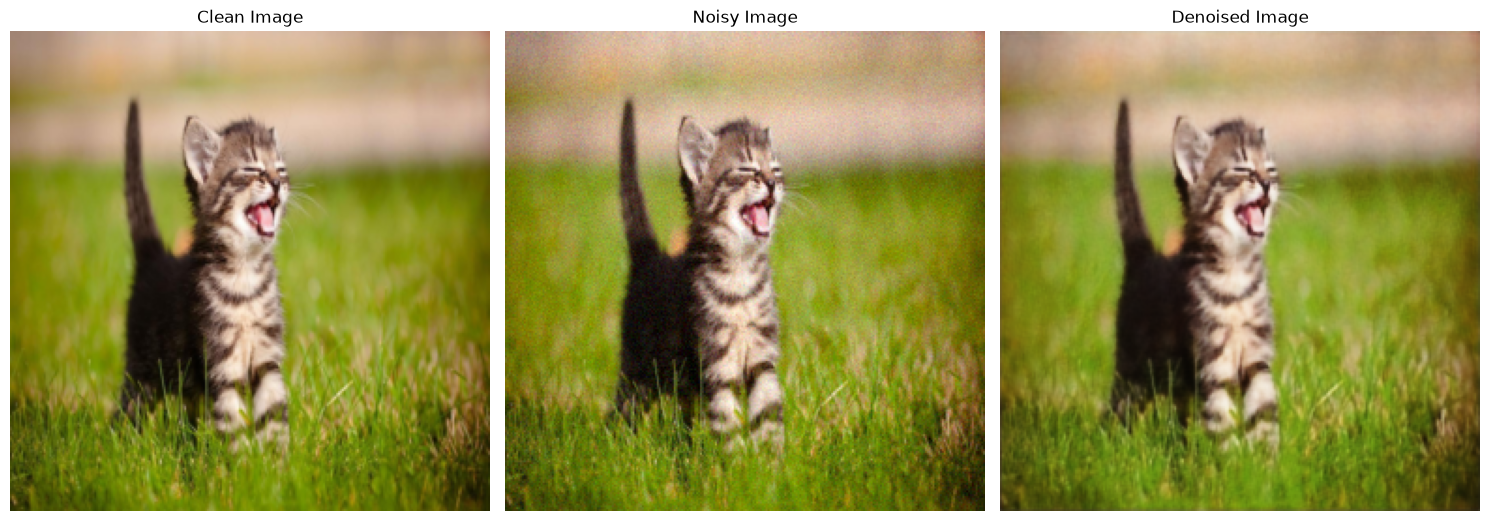

In [202]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize = (15,10))
ax1.imshow(img.permute(1,2,0))
ax1.set_title('Clean Image')
ax1.axis('off')

ax2.imshow(img_noisy.permute(1, 2, 0))
ax2.set_title('Noisy Image')
ax2.axis('off')

ax3.imshow(output.squeeze(0).permute(1,2,0))
ax3.set_title('Denoised Image')
ax3.axis('off')
plt.tight_layout()
plt.show()